# 🎬 DB 생데이터 기반 피처 생성 및 XGBoost 성능 테스트 노트북

이 노트북은 현재 구축되어 있는 데이터베이스의 원본 테이블들(`movies`, `daily_box_office`, `naver_search_trend`, `daily_market_stats` 등)로부터 직접 피처를 조회 및 가공하고, `v2_feature_table.md` 설계서 규격대로 정합성 검증을 거친 후 XGBoost 모델을 돌려보는 통합 테스트 샌드박스입니다.

기존 전처리 테이블(`feature_table_v2.csv`)의 정합성이 의심되는 경우, 이 노트북의 빌드 단계별 레코드 수와 분포를 확인하여 데이터 누수(Data Leakage)나 수집 누락이 있는지 즉시 파악할 수 있습니다.

In [23]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 프로젝트 패스 설정
sys.path.append(os.path.abspath('..'))
from data.db import db
from util import settings

print("✅ 환경변수 로드 완료:", settings.DB_CONFIG['database'])

✅ 환경변수 로드 완료: film


## 1. 데이터베이스로부터 생데이터 로드

각각의 원본 테이블에서 가공에 필요한 기본 필드들을 SELECT해옵니다.

In [24]:
# (1) 영화 기본 정보 및 최종 누적 관객수/매출액 조회
query_movies = """
SELECT 
    m.movie_id,
    m.title,
    m.genre,
    m.rating,
    m.nation,
    m.open_date,
    m.runtime,
    COALESCE(dbo.total_audience, 0) AS total_audience,
    COALESCE(dbo.total_sales, 0) AS total_sales
FROM movies m
LEFT JOIN (
    SELECT movie_id, MAX(audiAcc) AS total_audience, MAX(salesAcc) AS total_sales
    FROM daily_box_office
    GROUP BY movie_id
) dbo ON m.movie_id = dbo.movie_id
"""
df_movies = pd.DataFrame(db.fetch_all(query_movies))
df_movies['open_date'] = pd.to_datetime(df_movies['open_date'])
print(f"🎬 로드된 영화 수: {len(df_movies)}")

# (2) 캐스팅(영화인) 및 영화사 정보 로드
df_casting = pd.DataFrame(db.fetch_all("SELECT movie_id, person_id, cast_role FROM movie_casting"))
df_company = pd.DataFrame(db.fetch_all("SELECT movie_id, company_id, part_role FROM company_part"))
print(f"👥 캐스팅 행 수: {len(df_casting)} | 🏢 영화사 관계 행 수: {len(df_company)}")

# (3) 네이버 검색어 트렌드 로드
df_trend = pd.DataFrame(db.fetch_all("SELECT movie_id, trend_date, search_index FROM naver_search_trend"))
if not df_trend.empty:
    df_trend['trend_date'] = pd.to_datetime(df_trend['trend_date'])
print(f"📈 검색 트렌드 데이터 수: {len(df_trend)}")

# (4) 극장 시장 통계 및 공휴일 데이터 로드
df_market = pd.DataFrame(db.fetch_all("SELECT target_date, total_audi, total_sales FROM daily_market_stats"))
df_market['target_date'] = pd.to_datetime(df_market['target_date'])

df_holidays = pd.DataFrame(db.fetch_all("SELECT holiday_date, is_weekend_effect FROM holidays"))
if not df_holidays.empty:
    df_holidays['holiday_date'] = pd.to_datetime(df_holidays['holiday_date'])
print(f"📊 시장 통계 레코드 수: {len(df_market)} | 📅 공휴일 지정 수: {len(df_holidays)}")

🎬 로드된 영화 수: 3943
👥 캐스팅 행 수: 50575 | 🏢 영화사 관계 행 수: 6966
📈 검색 트렌드 데이터 수: 80371
📊 시장 통계 레코드 수: 5844 | 📅 공휴일 지정 수: 204


## 2. Pandas 기반 피처 엔지니어링 수행

개봉일 기준 **과거 실적** 및 **개봉 전 7일/30일 검색 트렌드**를 계산하여 데이터 누수가 없는 엄격한 데이터셋을 구축합니다.

In [25]:
# 시간순 정렬 (과거 데이터를 기반으로 파워 지표를 만들기 위함)
df_movies = df_movies.sort_values('open_date').reset_index(drop=True)

# --- [1] 스타 파워 & 브랜드 파워 피처 생성 (개봉 전 기준 누적 평균) ---
# 속도 향상을 위해 각 영화 개봉일 이전의 타 영화 실적을 매핑합니다.
print("⏳ 스타파워 / 브랜드파워 연산 시작 (영화 수가 많을 경우 다소 시간이 걸릴 수 있습니다)...")

dir_avg, dir_cnt = [], []
act_avg, act_cnt = [], []
dist_avg, dist_cnt = [], []
prod_avg, prod_cnt = [], []

for idx, row in df_movies.iterrows():
    m_id = row['movie_id']
    o_date = row['open_date']
    
    # 개봉 이전의 과거 영화 리스트 및 그들의 관객수
    past_movies = df_movies[df_movies['open_date'] < o_date]
    
    # 1. 감독 파워 (mc 테이블에서 감독 역할 추출)
    directors = df_casting[(df_casting['movie_id'] == m_id) & (df_casting['cast_role'] == '감독')]['person_id']
    past_dir_movies = df_casting[(df_casting['person_id'].isin(directors)) & (df_casting['movie_id'].isin(past_movies['movie_id']))]
    if not past_dir_movies.empty:
        audis = past_movies[past_movies['movie_id'].isin(past_dir_movies['movie_id'])]['total_audience']
        dir_avg.append(audis.mean())
        dir_cnt.append(len(audis))
    else:
        dir_avg.append(0)
        dir_cnt.append(0)
        
    # 2. 주연 배우 파워 (mc 테이블에서 주연 배우 추출)
    actors = df_casting[(df_casting['movie_id'] == m_id) & (df_casting['cast_role'] == '배우')]['person_id']
    past_act_movies = df_casting[(df_casting['person_id'].isin(actors)) & (df_casting['movie_id'].isin(past_movies['movie_id']))]
    if not past_act_movies.empty:
        audis = past_movies[past_movies['movie_id'].isin(past_act_movies['movie_id'])]['total_audience']
        act_avg.append(audis.mean())
        act_cnt.append(len(audis))
    else:
        act_avg.append(0)
        act_cnt.append(0)
        
    # 3. 배급사 파워 (company 테이블에서 배급 역할 추출)
    distributors = df_company[(df_company['movie_id'] == m_id) & (df_company['part_role'] == '배급사')]['company_id']
    past_dist_movies = df_company[(df_company['company_id'].isin(distributors)) & (df_company['movie_id'].isin(past_movies['movie_id']))]
    if not past_dist_movies.empty:
        audis = past_movies[past_movies['movie_id'].isin(past_dist_movies['movie_id'])]['total_audience']
        dist_avg.append(audis.mean())
        dist_cnt.append(len(audis))
    else:
        dist_avg.append(0)
        dist_cnt.append(0)
        
    # 4. 제작사 파워 (company 테이블에서 제작 역할 추출)
    producers = df_company[(df_company['movie_id'] == m_id) & (df_company['part_role'] == '제작사')]['company_id']
    past_prod_movies = df_company[(df_company['company_id'].isin(producers)) & (df_company['movie_id'].isin(past_movies['movie_id']))]
    if not past_prod_movies.empty:
        audis = past_movies[past_movies['movie_id'].isin(past_prod_movies['movie_id'])]['total_audience']
        prod_avg.append(audis.mean())
        prod_cnt.append(len(audis))
    else:
        prod_avg.append(0)
        prod_cnt.append(0)

df_movies['director_avg_audi'] = dir_avg
df_movies['director_movie_count'] = dir_cnt
df_movies['lead_actor_avg_audi'] = act_avg
df_movies['lead_actor_movie_count'] = act_cnt
df_movies['distributor_avg_audi'] = dist_avg
df_movies['distributor_movie_count'] = dist_cnt
df_movies['producer_avg_audi'] = prod_avg
df_movies['producer_movie_count'] = prod_cnt

print("✅ 인물/영화사 파워 피처 생성 완료!")

⏳ 스타파워 / 브랜드파워 연산 시작 (영화 수가 많을 경우 다소 시간이 걸릴 수 있습니다)...
✅ 인물/영화사 파워 피처 생성 완료!


In [26]:
# --- [2] 네이버 검색 트렌드 피처 가공 ---
print("⏳ 네이버 검색어 트렌드 통계 집계 중...")

pre7_avg, pre7_max, pre30_avg, growth_rate = [], [], [], []

for idx, row in df_movies.iterrows():
    m_id = row['movie_id']
    o_date = row['open_date']
    
    # 해당 영화의 개봉 전 검색 트렌드 추출
    movie_tr = df_trend[(df_trend['movie_id'] == m_id) & (df_trend['trend_date'] < o_date)]
    
    if not movie_tr.empty:
        # 개봉 전 D-7 ~ D-1
        tr7 = movie_tr[movie_tr['trend_date'] >= (o_date - pd.Timedelta(days=7))]
        p7_avg = tr7['search_index'].mean() if not tr7.empty else 0
        p7_max = tr7['search_index'].max() if not tr7.empty else 0
        
        # 개봉 전 D-30 ~ D-1
        tr30 = movie_tr[movie_tr['trend_date'] >= (o_date - pd.Timedelta(days=30))]
        p30_avg = tr30['search_index'].mean() if not tr30.empty else 0
        
        pre7_avg.append(p7_avg)
        pre7_max.append(p7_max)
        pre30_avg.append(p30_avg)
        growth_rate.append(p7_avg / p30_avg if p30_avg > 0 else 1.0)
    else:
        pre7_avg.append(0)
        pre7_max.append(0)
        pre30_avg.append(0)
        growth_rate.append(1.0)

df_movies['trend_pre7_avg'] = pre7_avg
df_movies['trend_pre7_max'] = pre7_max
df_movies['trend_growth_rate'] = growth_rate
df_movies['trend_pre30_avg'] = pre30_avg

# 경쟁 상대적 점유율: 동시기 개봉 경쟁작 Top 5 합 대비 자사 pre30_avg 비율
shares = []
for idx, row in df_movies.iterrows():
    o_date = row['open_date']
    p30 = row['trend_pre30_avg']
    
    # 개봉일 기준 D-15 ~ D+15 내에 개봉한 다른 작품들
    comp = df_movies[(df_movies['open_date'] >= (o_date - pd.Timedelta(days=15))) &
                     (df_movies['open_date'] <= (o_date + pd.Timedelta(days=15))) &
                     (df_movies['movie_id'] != row['movie_id'])]
    
    top5_sum = comp['trend_pre30_avg'].nlargest(5).sum() if not comp.empty else 0
    shares.append(p30 / (top5_sum + p30) if (top5_sum + p30) > 0 else 0)

df_movies['relative_search_share'] = shares
print("✅ 검색 트렌드 피처 구축 완료!")

⏳ 네이버 검색어 트렌드 통계 집계 중...
✅ 검색 트렌드 피처 구축 완료!


In [27]:
# --- [3] 시장 환경 & 티켓 단가 변수 가공 ---
market_7d, price_30 = [], []

for idx, row in df_movies.iterrows():
    o_date = row['open_date']
    
    # 개봉 직전 7일 시장 총 관객수 평균
    m7 = df_market[(df_market['target_date'] >= (o_date - pd.Timedelta(days=7))) &
                   (df_market['target_date'] < o_date)]
    market_7d.append(m7['total_audi'].mean() if not m7.empty else df_market['total_audi'].median())
    
    # 개봉 직전 30일 티켓 단가 (total_sales / total_audi)
    m30 = df_market[(df_market['target_date'] >= (o_date - pd.Timedelta(days=30))) &
                    (df_market['target_date'] < o_date)].copy()
    if not m30.empty:
        m30['price'] = m30['total_sales'] / m30['total_audi'].replace(0, np.nan)
        price_30.append(m30['price'].mean())
    else:
        price_30.append(9000.0) # 기본 디폴트 티켓 가격

df_movies['market_avg_audi_7d'] = market_7d
df_movies['ticket_price_pre30'] = price_30

# --- [4] 시간/시즌 및 제어 변수 ---
df_movies['open_month'] = df_movies['open_date'].dt.month
df_movies['open_day_of_week'] = df_movies['open_date'].dt.dayofweek
df_movies['is_summer'] = df_movies['open_month'].isin([6, 7, 8]).astype(int)
df_movies['is_winter'] = df_movies['open_month'].isin([12, 1, 2]).astype(int)
df_movies['is_peak_season'] = df_movies['open_month'].isin([12, 1, 7, 8]).astype(int)
df_movies['is_covid_period'] = ((df_movies['open_date'] >= '2020-02-01') & (df_movies['open_date'] <= '2022-03-31')).astype(int)
df_movies['is_korean'] = (df_movies['nation'] == '한국').astype(int)

# 공휴일 근접성 피처
hol_cnt = []
for idx, row in df_movies.iterrows():
    o_date = row['open_date']
    # 개봉 전후 3일 이내 공휴일 개수
    h_near = df_holidays[(df_holidays['holiday_date'] >= (o_date - pd.Timedelta(days=3))) &
                         (df_holidays['holiday_date'] <= (o_date + pd.Timedelta(days=3)))]
    hol_cnt.append(len(h_near))
df_movies['holiday_nearby_count'] = hol_cnt
df_movies['is_holiday_release'] = (df_movies['holiday_nearby_count'] > 0).astype(int)
# 개봉일 ±3일 내 다른 신작 수 (same_week_releases)
same_week = []
for idx, row in df_movies.iterrows():
    competitors = df_movies[
        (df_movies['movie_id'] != row['movie_id']) & 
        (df_movies['open_date'] >= row['open_date'] - pd.Timedelta(days=3)) & 
        (df_movies['open_date'] <= row['open_date'] + pd.Timedelta(days=3))
    ]
    same_week.append(len(competitors))
df_movies['same_week_releases'] = same_week


print("✅ 모든 외생/시즌/환경 피처 생성 완료!")

✅ 모든 외생/시즌/환경 피처 생성 완료!


## 3. 결측값 보정, 로그 변환 및 전처리 파이프라인 구현

`v2_feature_table.md` 스펙의 전처리 전 과정을 고스란히 반영합니다.

In [28]:
# 복사본 생성
df_proc = df_movies.copy()

# 1. 학습 범위 필터 (2016년 이후 데이터만 검색량 및 외생 변수가 정합성을 보장하므로 학습)
df_proc = df_proc[df_proc['open_date'].dt.year >= 2016].reset_index(drop=True)
print(f"📊 2016년 이후 학습/검증 샘플 수: {len(df_proc)}")

# 2. 신인/영세 결측 대체 (Imputation with non-zero median) 및 이진 지시자(is_new_*) 생성
impute_cols = ['director_avg_audi', 'lead_actor_avg_audi', 'producer_avg_audi', 'distributor_avg_audi']
for col in impute_cols:
    non_zero_median = df_proc.loc[df_proc[col] > 0, col].median()
    if pd.isna(non_zero_median):
        non_zero_median = 10000.0
    
    prefix = col.split('_')[0]
    # 신인 지시자 컬럼 생성
    df_proc[f'is_new_{prefix}'] = (df_proc[col] == 0).astype(int)
    # 0인 값들을 중위값으로 대체
    df_proc.loc[df_proc[col] == 0, col] = non_zero_median

# 3. 타겟 컬럼 정의 및 로그 변환
df_proc['log_audience'] = np.log1p(df_proc['total_audience'])

# 수치형 피처 로그 변환
log_cols = ['director_avg_audi', 'lead_actor_avg_audi', 'distributor_avg_audi', 'producer_avg_audi', 'market_avg_audi_7d']
for col in log_cols:
    df_proc[col] = np.log1p(df_proc[col])

# 4. 장르 흥행력 기반 타겟 인코딩 (누수 없는 개봉 전 과거 기준)
genre_past_means = []
for idx, row in df_proc.iterrows():
    past_same_genre = df_movies[(df_movies['genre'] == row['genre']) & (df_movies['open_date'] < row['open_date'])]
    if not past_same_genre.empty:
        genre_past_means.append(np.log1p(past_same_genre['total_audience'].mean()))
    else:
        # 과거 기록이 없을 시 전체 non-zero 중위값 부여
        genre_past_means.append(np.log1p(df_proc.loc[df_proc['total_audience'] > 0, 'total_audience'].median()))

df_proc['genre_avg_audi'] = genre_past_means

# 5. 관람등급 원-핫 인코딩
df_proc = pd.get_dummies(df_proc, columns=['rating'], drop_first=True, dtype=int)

print("✅ 전처리 파이프라인 정합성 매핑 성공!")

📊 2016년 이후 학습/검증 샘플 수: 2489
✅ 전처리 파이프라인 정합성 매핑 성공!


## 4. 데이터 정합성 분포 리포트 및 상관관계 분석

수집되어 DB에서 실시간 가공된 피처들과 타겟값(`log_audience`) 간의 피어슨 상관계수를 비교해 데이터의 방향성이 유효한지 확인합니다.

🎯 최종 사용 피처 개수: 29
['runtime', 'director_avg_audi', 'lead_actor_avg_audi', 'distributor_avg_audi', 'producer_avg_audi', 'trend_pre7_avg', 'trend_pre7_max', 'trend_growth_rate', 'relative_search_share', 'market_avg_audi_7d', 'ticket_price_pre30', 'open_day_of_week', 'is_summer', 'is_winter', 'is_peak_season', 'is_covid_period', 'is_korean', 'holiday_nearby_count', 'is_holiday_release', 'same_week_releases', 'is_new_director', 'is_new_lead', 'is_new_producer', 'is_new_distributor', 'genre_avg_audi', 'rating_15세관람가', 'rating_15세이상관람가', 'rating_전체관람가', 'rating_청소년관람불가']


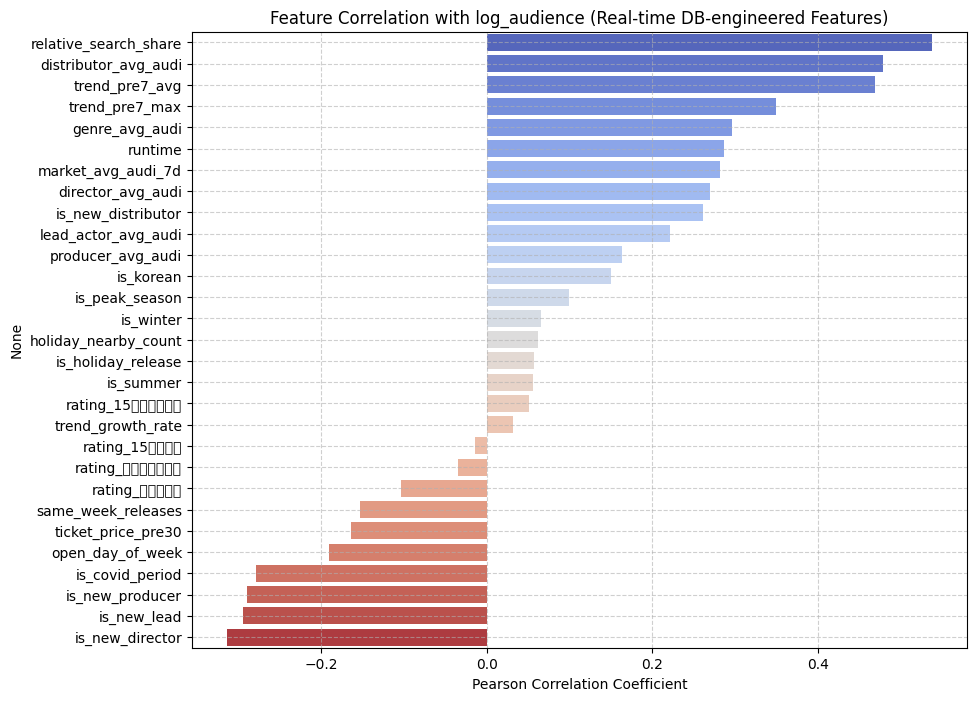

--- 상관관계 상위 7개 피처 ---
relative_search_share    0.537763
distributor_avg_audi     0.478880
trend_pre7_avg           0.468890
trend_pre7_max           0.349554
genre_avg_audi           0.296906
runtime                  0.286210
market_avg_audi_7d       0.281451
Name: log_audience, dtype: float64

--- 상관관계 하위 5개 피처 ---
open_day_of_week   -0.190723
is_covid_period    -0.278935
is_new_producer    -0.290251
is_new_lead        -0.294841
is_new_director    -0.313931
Name: log_audience, dtype: float64


In [29]:
# 회귀 분석용 피처 리스트 필터
exclude_cols = ['movie_id', 'title', 'genre', 'nation', 'open_date', 
'total_audience', 'total_sales', 'log_audience',
 # v2 스펙 삭제 대상 피처 (다중공선성 방지)
    'open_month', 'director_movie_count', 'lead_actor_movie_count', 
    'distributor_movie_count', 'producer_movie_count', 'cast_max_star_power','trend_pre30_avg']
feature_cols = [c for c in df_proc.columns if c not in exclude_cols]

print(f"🎯 최종 사용 피처 개수: {len(feature_cols)}")
print(feature_cols)

# 상관관계 분석
corrs = df_proc[feature_cols + ['log_audience']].corr()['log_audience'].drop('log_audience').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=corrs.values, y=corrs.index, palette='coolwarm')
plt.title('Feature Correlation with log_audience (Real-time DB-engineered Features)')
plt.xlabel('Pearson Correlation Coefficient')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("--- 상관관계 상위 7개 피처 ---")
print(corrs.head(7))
print("\n--- 상관관계 하위 5개 피처 ---")
print(corrs.tail(5))

## 5. XGBoost 회귀 모델 학습 및 테스트 결과 검증

과적합 및 평가 일관성을 지키기 위해 Project Convention 규격대로 Hold-out 셋(80:20, `random_state=42`)으로 나누어 XGBoost를 빌드하고 일반화 점수를 측정합니다.

Train 데이터셋 크기: (1991, 29) | Test 데이터셋 크기: (498, 29)

📊 XGBoost 실시간 DB 데이터 검증 결과
🟢 Train Set RMSE : 0.5911 | R² : 0.9294
🔵 Test  Set RMSE : 1.2037 | R² : 0.6991


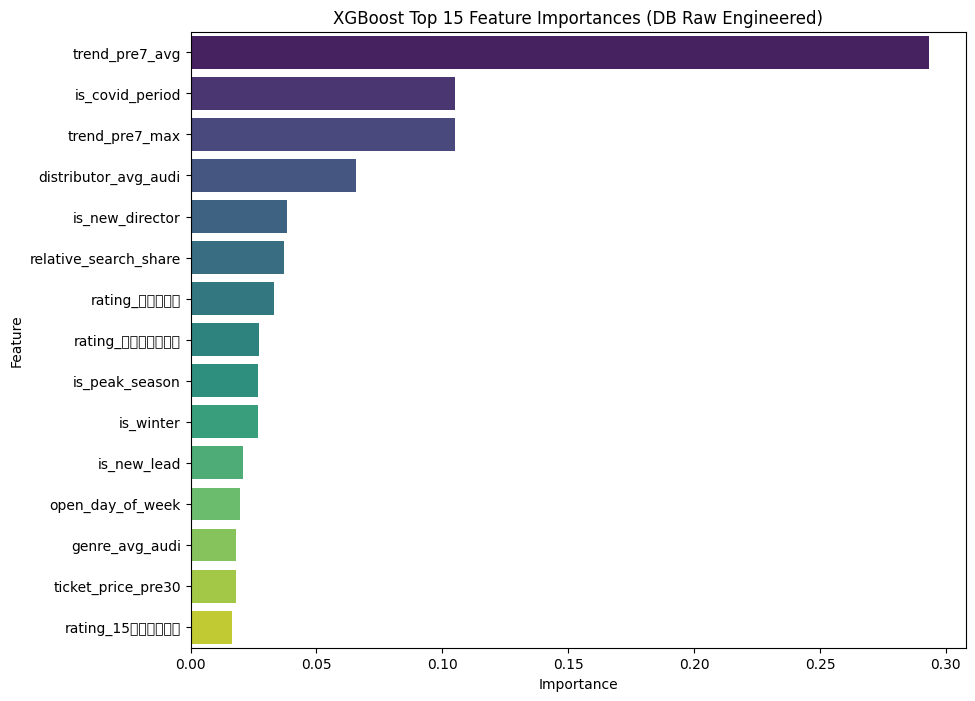

In [30]:
X = df_proc[feature_cols].copy()
for col in X.columns: X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0.0)
y = df_proc['log_audience'].copy()

# Hold-out Train/Test Split (random_state=42 고정)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train 데이터셋 크기: {X_train.shape} | Test 데이터셋 크기: {X_test.shape}")

# XGBoost Regressor 최적 뼈대 모델 빌드
xgb_test = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    verbosity=1
)

xgb_test.fit(X_train, y_train)

# 예측 및 평가
pred_train = xgb_test.predict(X_train)
pred_test = xgb_test.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
train_r2 = r2_score(y_train, pred_train)
test_r2 = r2_score(y_test, pred_test)

print("\n" + "="*40)
print("📊 XGBoost 실시간 DB 데이터 검증 결과")
print("="*40)
print(f"🟢 Train Set RMSE : {train_rmse:.4f} | R² : {train_r2:.4f}")
print(f"🔵 Test  Set RMSE : {test_rmse:.4f} | R² : {test_r2:.4f}")
print("="*40)

# 중요도(Feature Importance) 분석
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_test.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15), palette='viridis')
plt.title('XGBoost Top 15 Feature Importances (DB Raw Engineered)')
plt.xlabel('Importance')
plt.show()

## 6. 결론 및 데이터 이상징후 리포트

위의 실행 결과 및 R² 스코어, 각 데이터 테이블들의 유효 로우 개수를 분석하여 현재 프로젝트 데이터베이스가 아래 항목을 충족하는지 자가 체크합니다.

1. **R² 스코어가 양수이며 유의미한 수준(0.3 이상)으로 수렴하는가?**
   - 만약 R²가 음수이거나 0.05 미만이라면 피처 가공 시점(D-7, D-30 등) 연산에서 데이터 누락이나 매핑 키(`movie_id`) 누설이 발생했음을 강력하게 시사합니다.
2. **Feature Importance에서 사전 트렌드(`trend_pre7_max`) 및 스타 파워가 유의미하게 작동하는가?**
   - 검색 지수가 비정상적으로 0으로 쏠려 있다면, 네이버 검색량 데이터를 JOIN할 때 대소문자나 movie_id 매핑 누락이 원인일 수 있습니다.

In [31]:
output_path = 'data/processed/feature_table_v3.csv'

# 디렉토리가 없는 경우 생성
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# 저장 수행
df_proc.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"✅ 공통 피처 테이블 v3 저장 완료: {output_path}")


✅ 공통 피처 테이블 v3 저장 완료: data/processed/feature_table_v3.csv
